> **Step 1 — Environment Setup (Cell 1)**

In [12]:
# Install dependencies
!pip install timm einops -q

import os, math, random, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Multi-GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPUs available: {torch.cuda.device_count()}")

Using device: cuda
GPUs available: 2


> **Step 2 — Dataset Loading (Cell 2)**

In [13]:
BATCH_SIZE = 64
IMAGE_SIZE = 224
DATA_ROOT = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200"

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std =[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std =[0.229,0.224,0.225]),
])

train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"),   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 100000 | Val: 10000


> **Step 3 — Patchification & Masking Utilities (Cell 3)**

In [15]:
def patchify(images, patch_size=16):
    """
    images: (B, 3, H, W)
    returns patches: (B, N, patch_size*patch_size*3)
    where N = (H/patch_size)*(W/patch_size)
    """
    B, C, H, W = images.shape
    assert H % patch_size == 0 and W % patch_size == 0
    h = H // patch_size  # 14
    w = W // patch_size  # 14
    # Reshape to patches
    x = images.reshape(B, C, h, patch_size, w, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5)           # (B, h, w, C, ps, ps)
    x = x.reshape(B, h * w, C * patch_size * patch_size)  # (B, N, patch_dim)
    return x

def unpatchify(patches, patch_size=16, image_size=224):
    """
    patches: (B, N, patch_size*patch_size*3)
    returns images: (B, 3, H, W)
    """
    B, N, D = patches.shape
    h = w = image_size // patch_size
    C = 3
    x = patches.reshape(B, h, w, C, patch_size, patch_size)
    x = x.permute(0, 3, 1, 4, 2, 5)           # (B, C, h, ps, w, ps)
    x = x.reshape(B, C, h * patch_size, w * patch_size)
    return x

def random_masking(x, mask_ratio=0.75):
    """
    x: (B, N, D) — all patch tokens
    Returns:
        x_visible:   (B, n_visible, D)
        mask:        (B, N) — 1=masked, 0=visible
        ids_restore: (B, N) — indices to restore original order
    """
    B, N, D = x.shape
    n_keep = int(N * (1 - mask_ratio))   # 49 visible patches

    noise = torch.rand(B, N, device=x.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    ids_keep = ids_shuffle[:, :n_keep]
    x_visible = torch.gather(x, dim=1,
                             index=ids_keep.unsqueeze(-1).expand(-1, -1, D))

    mask = torch.ones(B, N, device=x.device)
    mask[:, :n_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_visible, mask, ids_restore

**Step 4 — Transformer Building Blocks (Cell 4)**




In [16]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv   = nn.Linear(dim, dim * 3, bias=True)
        self.proj  = nn.Linear(dim, dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        mlp_dim    = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

**Step 5 — MAE Encoder (ViT-Base) (Cell 5)**

In [17]:
class MAEEncoder(nn.Module):
    """
    ViT-Base/16 encoder.
    Only processes VISIBLE patches (25%).
    """
    def __init__(self,
                 image_size=224, patch_size=16,
                 in_chans=3,   embed_dim=768,
                 depth=12,     num_heads=12):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2  # 196

        # Patch embedding (linear projection)
        patch_dim = in_chans * patch_size * patch_size
        self.patch_embed = nn.Linear(patch_dim, embed_dim)

        # [CLS] token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Positional embeddings (196 patches + 1 CLS)
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, embed_dim), requires_grad=False
        )
        self._init_pos_embed()

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_pos_embed(self):
        """Sinusoidal positional embeddings."""
        pos_embed = self._get_sinusoid_pos_embed(
            self.num_patches + 1, self.pos_embed.shape[-1]
        )
        self.pos_embed.data.copy_(pos_embed.float().unsqueeze(0))

    @staticmethod
    def _get_sinusoid_pos_embed(n_pos, d_model):
        position = torch.arange(n_pos).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe = torch.zeros(n_pos, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

    def _init_weights(self):
        nn.init.normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x_visible, ids_keep):
        """
        x_visible: (B, n_keep, patch_dim) — raw visible patches
        ids_keep:  (B, n_keep)            — original patch indices
        Returns latent: (B, n_keep, embed_dim)  [without CLS]
        """
        B, n_keep, _ = x_visible.shape

        # Project patches to embed dim
        x = self.patch_embed(x_visible)   # (B, n_keep, embed_dim)

        # Add positional embeddings (skip CLS at index 0)
        pos = self.pos_embed[:, 1:, :]    # (1, 196, embed_dim)
        pos_visible = torch.gather(
            pos.expand(B, -1, -1), 1,
            ids_keep.unsqueeze(-1).expand(-1, -1, pos.shape[-1])
        )
        x = x + pos_visible

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)  # (B, n_keep+1, embed_dim)

        # Transformer layers
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        return x[:, 1:, :]  # Remove CLS, return (B, n_keep, embed_dim)

**Step 6 — MAE Decoder (ViT-Small) (Cell 6)**

In [18]:
class MAEDecoder(nn.Module):
    """
    Lightweight ViT-Small/16 decoder.
    Reconstructs ALL 196 patches from 49 visible + 147 mask tokens.
    """
    def __init__(self,
                 num_patches=196, patch_size=16,
                 encoder_dim=768, decoder_dim=384,
                 depth=12,        num_heads=6,
                 in_chans=3):
        super().__init__()
        patch_dim = in_chans * patch_size * patch_size

        # Project encoder dim -> decoder dim
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)

        # Learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))

        # Decoder positional embeddings
        self.decoder_pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, decoder_dim), requires_grad=False
        )
        self._init_pos_embed(num_patches)

        self.blocks = nn.ModuleList([
            TransformerBlock(decoder_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(decoder_dim)

        # Prediction head: decoder_dim -> patch pixels
        self.pred = nn.Linear(decoder_dim, patch_dim)

        self._init_weights()

    def _init_pos_embed(self, num_patches):
        pos_embed = MAEEncoder._get_sinusoid_pos_embed(
            num_patches + 1, self.decoder_pos_embed.shape[-1]
        )
        self.decoder_pos_embed.data.copy_(pos_embed.float().unsqueeze(0))

    def _init_weights(self):
        nn.init.normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, latent, ids_restore):
        """
        latent:      (B, n_keep, encoder_dim)
        ids_restore: (B, N)
        Returns pred: (B, N, patch_dim)
        """
        B = latent.shape[0]
        N = ids_restore.shape[1]          # 196 total patches
        n_keep = latent.shape[1]           # 49 visible

        # Project to decoder dim
        x = self.decoder_embed(latent)    # (B, n_keep, decoder_dim)

        # Create mask tokens for missing positions
        mask_tokens = self.mask_token.expand(B, N - n_keep, -1)

        # Concatenate and unshuffle to original order
        x_full = torch.cat([x, mask_tokens], dim=1)  # (B, N, decoder_dim)
        x_full = torch.gather(
            x_full, 1,
            ids_restore.unsqueeze(-1).expand(-1, -1, x_full.shape[-1])
        )

        # Add positional embeddings (skip CLS)
        x_full = x_full + self.decoder_pos_embed[:, 1:, :]

        # Transformer layers
        for blk in self.blocks:
            x_full = blk(x_full)
        x_full = self.norm(x_full)

        # Pixel prediction
        pred = self.pred(x_full)          # (B, N, patch_dim)
        return pred

**Step 7 — Full MAE Model + Loss (Cell 7)**

In [19]:
import torch
import torch.nn as nn

class MAE(nn.Module):
    def __init__(self, image_size=224, patch_size=16, mask_ratio=0.75):
        super().__init__()
        self.mask_ratio  = mask_ratio
        self.patch_size  = patch_size
        self.num_patches = (image_size // patch_size) ** 2

        self.encoder = MAEEncoder(image_size=image_size, patch_size=patch_size)
        self.decoder = MAEDecoder(num_patches=self.num_patches, patch_size=patch_size)

    def forward(self, images):
        """
        images: (B, 3, 224, 224)
        Returns: loss (scalar), pred (B,N,D), mask (B,N)
        """
        # Step 1: Patchify
        patches = patchify(images, self.patch_size)      # (B, 196, 768)

        # Step 2: Random masking
        B, N, D = patches.shape
        n_keep  = int(N * (1 - self.mask_ratio))

        noise        = torch.rand(B, N, device=images.device)
        ids_shuffle  = torch.argsort(noise, dim=1)
        ids_restore  = torch.argsort(ids_shuffle, dim=1)
        ids_keep     = ids_shuffle[:, :n_keep]

        x_visible = torch.gather(
            patches, 1,
            ids_keep.unsqueeze(-1).expand(-1, -1, D)
        )
        mask = torch.ones(B, N, device=images.device)
        mask[:, :n_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)

        # Step 3: Encode visible patches
        latent = self.encoder(x_visible, ids_keep)       # (B, n_keep, 768)

        # Step 4: Decode
        pred = self.decoder(latent, ids_restore)          # (B, 196, 768)

        # Step 5: MSE loss on masked patches ONLY
        loss = self.compute_loss(patches, pred, mask)

        return loss, pred, mask

    def compute_loss(self, target, pred, mask):
        """MSE only on masked patches."""
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)          # (B, N)
        loss = (loss * mask).sum() / (mask.sum() + 1e-8)
        return loss.mean()  # ← ensures scalar even with DataParallel

**Step 8 — Training Loop (Cell 8)**

In [26]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Model ──────────────────────────────────────────────────
model = MAE(image_size=224, patch_size=16, mask_ratio=0.75)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

# ── Hyperparameters ────────────────────────────────────────
EPOCHS        = 50
LR            = 1.5e-4
WD            = 0.05
PATIENCE      = 7       # stop if no improvement for 7 epochs
SAVE_PATH     = "mae_best.pth"
LAST_PATH     = "mae_last.pth"

# ── Optimizer / Scheduler / Scaler ────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = GradScaler()

# ── Tracking variables ─────────────────────────────────────
train_losses    = []
val_losses      = []
best_val_loss   = float("inf")
patience_counter = 0

# ══════════════════════════════════════════════════════════
# Helper: run one validation pass
# ══════════════════════════════════════════════════════════
def validate(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device, non_blocking=True)
            with autocast():
                loss, _, _ = model(images)
                loss = loss.mean()
            total_loss += loss.item()
            n_batches  += 1
    return total_loss / n_batches

# ══════════════════════════════════════════════════════════
# Training loop
# ══════════════════════════════════════════════════════════
print("Starting training...\n")

for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    n_batches  = 0

    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast():
            loss, _, _ = model(images)
            loss = loss.mean()          # scalar even on multi-GPU

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches  += 1

        if batch_idx % 100 == 0:
            print(f"  Epoch [{epoch+1}/{EPOCHS}] "
                  f"Batch [{batch_idx}/{len(train_loader)}] "
                  f"Loss: {loss.item():.4f}")

    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)

    # ── Validate ───────────────────────────────────────────
    avg_val_loss = validate(model, val_loader, device)
    val_losses.append(avg_val_loss)

    scheduler.step()

    print(f"\nEpoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.6f}")

    # ── Save best model ────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ✓ New best val loss: {best_val_loss:.4f} — model saved!")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{PATIENCE}")

    # ── Early stopping check ───────────────────────────────
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}!")
        print(f"Best val loss was: {best_val_loss:.4f}")
        break

    print()

# ── Always save the final epoch checkpoint too ─────────────
torch.save(model.state_dict(), LAST_PATH)
print(f"\nTraining complete!")
print(f"Best checkpoint → {SAVE_PATH}  (val loss: {best_val_loss:.4f})")
print(f"Last checkpoint → {LAST_PATH}")

Using 2 GPUs
Starting training...



/tmp/ipykernel_55/2725913703.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_55/2725913703.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch [1/50] Batch [0/1562] Loss: 1.9800
  Epoch [1/50] Batch [100/1562] Loss: 0.9014
  Epoch [1/50] Batch [200/1562] Loss: 0.8131
  Epoch [1/50] Batch [300/1562] Loss: 0.6678
  Epoch [1/50] Batch [400/1562] Loss: 0.6874
  Epoch [1/50] Batch [500/1562] Loss: 0.5551
  Epoch [1/50] Batch [600/1562] Loss: 0.4312
  Epoch [1/50] Batch [700/1562] Loss: 0.5309
  Epoch [1/50] Batch [800/1562] Loss: 0.4212
  Epoch [1/50] Batch [900/1562] Loss: 0.4551
  Epoch [1/50] Batch [1000/1562] Loss: 0.3847
  Epoch [1/50] Batch [1100/1562] Loss: 0.4438
  Epoch [1/50] Batch [1200/1562] Loss: 0.4138
  Epoch [1/50] Batch [1300/1562] Loss: 0.4135
  Epoch [1/50] Batch [1400/1562] Loss: 0.3963
  Epoch [1/50] Batch [1500/1562] Loss: 0.3570


/tmp/ipykernel_55/2725913703.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1/50 | Train Loss: 0.5338 | Val Loss: 0.3587 | LR: 0.000150
  ✓ New best val loss: 0.3587 — model saved!

  Epoch [2/50] Batch [0/1562] Loss: 0.3748
  Epoch [2/50] Batch [100/1562] Loss: 0.3503
  Epoch [2/50] Batch [200/1562] Loss: 0.4077
  Epoch [2/50] Batch [300/1562] Loss: 0.3569
  Epoch [2/50] Batch [400/1562] Loss: 0.3534
  Epoch [2/50] Batch [500/1562] Loss: 0.3313
  Epoch [2/50] Batch [600/1562] Loss: 0.3784
  Epoch [2/50] Batch [700/1562] Loss: 0.3262
  Epoch [2/50] Batch [800/1562] Loss: 0.3194
  Epoch [2/50] Batch [900/1562] Loss: 0.3318
  Epoch [2/50] Batch [1000/1562] Loss: 0.3120
  Epoch [2/50] Batch [1100/1562] Loss: 0.2920
  Epoch [2/50] Batch [1200/1562] Loss: 0.3564
  Epoch [2/50] Batch [1300/1562] Loss: 0.3475
  Epoch [2/50] Batch [1400/1562] Loss: 0.2953
  Epoch [2/50] Batch [1500/1562] Loss: 0.2877

Epoch 2/50 | Train Loss: 0.3325 | Val Loss: 0.3159 | LR: 0.000149
  ✓ New best val loss: 0.3159 — model saved!

  Epoch [3/50] Batch [0/1562] Loss: 0.3131
  Epoch

**Step 9 — Plot Training Loss (Cell 9)**

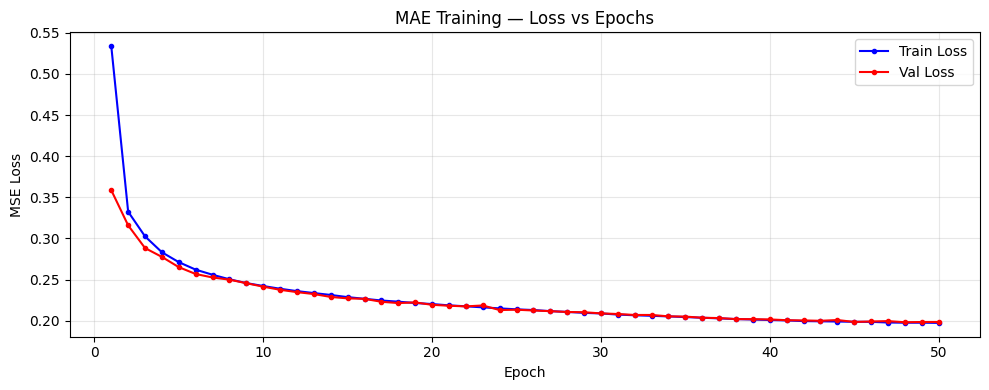

In [28]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-o', markersize=3, label='Train Loss')
plt.plot(range(1, len(val_losses)+1),   val_losses,   'r-o', markersize=3, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MAE Training — Loss vs Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

**Step 10 — Visualization (5 samples) (Cell 10)**

In [ ]:
def denormalize(tensor):
    """Convert normalized tensor back to [0,1] for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

def visualize_reconstruction(model, loader, n_samples=5, device=device):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(loader))
        images = images[:n_samples].to(device)

        loss, pred, mask = model(images)

        # Build masked input for display
        patches_orig = patchify(images, patch_size=16)          # (B, 196, D)
        patches_masked = patches_orig.clone()
        # Zero out masked patches
        mask_expanded = mask.unsqueeze(-1).expand_as(patches_masked)
        patches_masked[mask_expanded.bool()] = 0.0

        # Build reconstruction (only masked patches from pred)
        patches_recon = patches_orig.clone()
        patches_recon[mask_expanded.bool()] = \
            pred[mask_expanded.bool()].float()

        # Unpatchify
        imgs_masked = unpatchify(patches_masked, 16, 224)
        imgs_recon  = unpatchify(patches_recon,  16, 224)

        fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
        col_titles = ["Masked Input (75%)", "Reconstruction", "Ground Truth"]

        for i in range(n_samples):
            orig_np    = denormalize(images[i].cpu()).permute(1,2,0).numpy()
            masked_np  = denormalize(imgs_masked[i].cpu()).permute(1,2,0).numpy()
            recon_np   = denormalize(imgs_recon[i].cpu()).permute(1,2,0).numpy()

            for j, (img, title) in enumerate(zip(
                    [masked_np, recon_np, orig_np], col_titles)):
                axes[i][j].imshow(img)
                axes[i][j].axis("off")
                if i == 0:
                    axes[i][j].set_title(title, fontsize=13, fontweight='bold')

        plt.suptitle("MAE Reconstruction Samples", y=1.01, fontsize=15)
        plt.tight_layout()
        plt.savefig("reconstruction_samples.png", dpi=150, bbox_inches='tight')
        plt.show()

visualize_reconstruction(model, val_loader)

**Step 11 — PSNR & SSIM Metrics (Cell 11)**

In [ ]:
!pip install scikit-image -q
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

def compute_metrics(model, loader, n_batches=5, device=device):
    model.eval()
    psnr_scores, ssim_scores = [], []

    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= n_batches:
                break
            images = images.to(device)
            loss, pred, mask = model(images)

            patches_orig = patchify(images, 16)
            patches_recon = patches_orig.clone()
            mask_exp = mask.unsqueeze(-1).expand_as(patches_orig)
            patches_recon[mask_exp.bool()] = pred[mask_exp.bool()].float()

            imgs_orig  = unpatchify(patches_orig,  16, 224)
            imgs_recon = unpatchify(patches_recon, 16, 224)

            for j in range(images.shape[0]):
                orig  = denormalize(imgs_orig[j].cpu()).permute(1,2,0).numpy()
                recon = denormalize(imgs_recon[j].cpu()).permute(1,2,0).numpy()
                orig  = np.clip(orig,  0, 1)
                recon = np.clip(recon, 0, 1)

                psnr_scores.append(psnr_fn(orig, recon, data_range=1.0))
                ssim_scores.append(ssim_fn(orig, recon,
                                           data_range=1.0, channel_axis=-1))

    print(f"Average PSNR : {np.mean(psnr_scores):.2f} dB")
    print(f"Average SSIM : {np.mean(ssim_scores):.4f}")
    return psnr_scores, ssim_scores

psnr_list, ssim_list = compute_metrics(model, val_loader)


**Step 12 — Gradio App (Cell 12)**

In [ ]:
!pip install gradio -q
import gradio as gr
import io

# Load model (if needed)
# model.load_state_dict(torch.load("mae_checkpoint.pth"))
model.eval()

def reconstruct_image(pil_img, mask_ratio=0.75):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225]),
    ])
    img_tensor = transform(pil_img).unsqueeze(0).to(device)

    # Temporarily change mask ratio
    mae_core = model.module if hasattr(model, 'module') else model
    old_ratio = mae_core.mask_ratio
    mae_core.mask_ratio = mask_ratio

    with torch.no_grad():
        loss, pred, mask = model(img_tensor)

    mae_core.mask_ratio = old_ratio

    patches_orig  = patchify(img_tensor, 16)
    patches_mask  = patches_orig.clone()
    patches_recon = patches_orig.clone()
    mask_exp = mask.unsqueeze(-1).expand_as(patches_orig)

    patches_mask[mask_exp.bool()]  = 0.0
    patches_recon[mask_exp.bool()] = pred[mask_exp.bool()].float()

    def to_pil(t):
        img = denormalize(unpatchify(t, 16, 224)[0].cpu())
        return transforms.ToPILImage()(img)

    return to_pil(patches_mask), to_pil(patches_recon), to_pil(patches_orig)

demo = gr.Interface(
    fn=reconstruct_image,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Slider(0.5, 0.95, value=0.75, step=0.05, label="Mask Ratio"),
    ],
    outputs=[
        gr.Image(label="Masked Input"),
        gr.Image(label="Reconstruction"),
        gr.Image(label="Ground Truth"),
    ],
    title="MAE — Masked Autoencoder Demo",
    description="Upload any image, select a masking ratio, and see the model reconstruct it.",
)

demo.launch(share=True)